In [1]:
import os

import torch
from torch import nn
from torch.utils.data import DataLoader

from src.nn_modules.kan import BaselineKAN
from src.nn_modules.mlp import BaselineMLP
from src.utils.datasets import EmbeddingDataset
from src.utils.global_constants import MODELS_DIR
from src.utils.train_test import train_offline, measure_forward_backward_time


# The random seed is fixed to ensure reproducibility of results
torch.manual_seed(42)
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
device

device(type='cpu')

In [2]:
# Create a directory for trained models if it doesn't exist
os.makedirs(MODELS_DIR, exist_ok=True)

#### Datasets and training parameters

In [3]:
# Offline training parameters
learning_rate = 8e-4
batch_size = 128
criterion = nn.CrossEntropyLoss()
num_epochs = 100
early_stopping = 10

# Precomputed elmbeddings of images from the CUB200 dataset generated by ResNet50 model
trainset = EmbeddingDataset("cub200_train_embed.pt")
testset = EmbeddingDataset("cub200_test_embed.pt")
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

#### Models definition

###### MLP:

In [4]:
mlp = BaselineMLP()
mlp_optimizer = torch.optim.NAdam(mlp.parameters(), lr=learning_rate)
mlp

BaselineMLP(
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=400, bias=True)
    (3): ReLU()
    (4): Linear(in_features=400, out_features=200, bias=True)
  )
)

###### KAN:

In [5]:
kan = BaselineKAN()
kan_optimizer = torch.optim.NAdam(kan.parameters(), lr=learning_rate)
kan

BaselineKAN(
  (classifier): Sequential(
    (0): KANLayer(
      (bn): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): KANLayer(
      (bn): BatchNorm1d(400, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
)

#### Calculation of trainable parameters number

###### MLP:

In [6]:
num_mlp_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"Number of trainable parameters in BaselineMLP: {num_mlp_params}")

Number of trainable parameters in BaselineMLP: 1060200


###### KAN:

In [7]:
num_kan_params = sum(p.numel() for p in kan.parameters() if p.requires_grad)
print(f"Number of trainable parameters in BaselineKAN: {num_kan_params}")

Number of trainable parameters in BaselineKAN: 6299296


#### Offline training

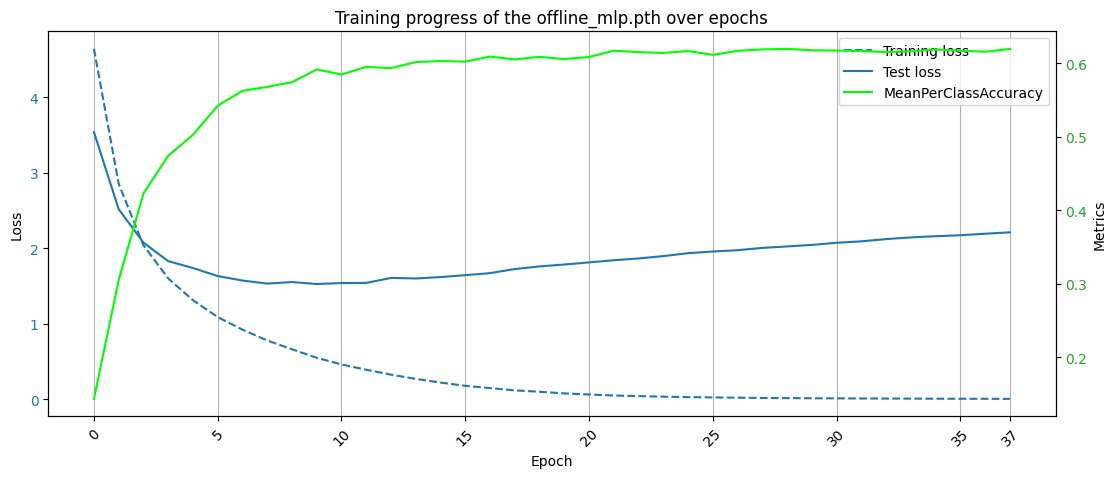

Early stopping is triggered at the epoch 37.
Best metric's value: 0.61879.
The model's weights are saved to /home/trxxxxkov/projects/spbu-bachelor-thesis/src/models/offline_mlp.pth


In [8]:
train_offline(
    model=mlp,
    trainloader=trainloader,
    testloader=testloader,
    criterion=criterion,
    optimizer=mlp_optimizer,
    save_path="offline_mlp.pth",
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

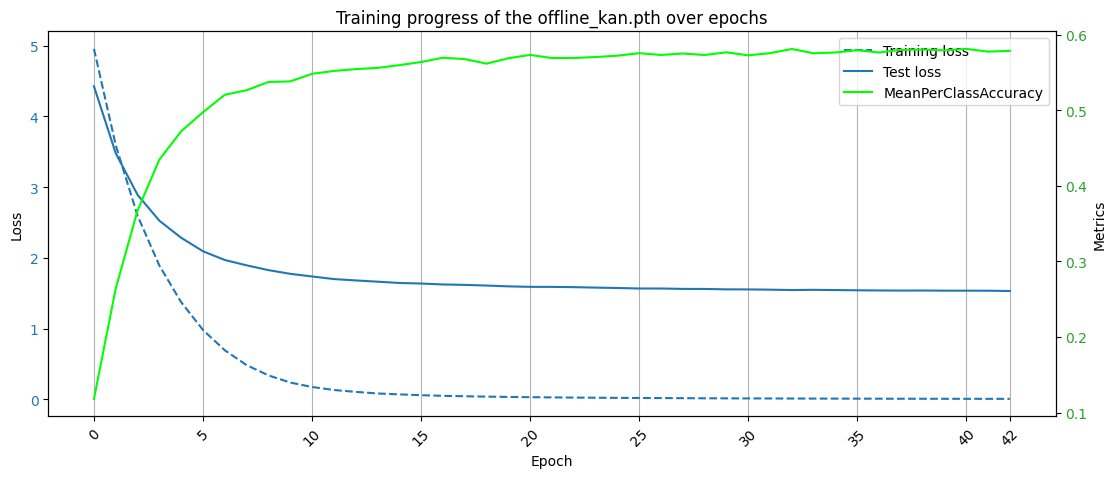

Early stopping is triggered at the epoch 42.
Best metric's value: 0.58099.
The model's weights are saved to /home/trxxxxkov/projects/spbu-bachelor-thesis/src/models/offline_kan.pth


In [9]:
train_offline(
    model=kan,
    trainloader=trainloader,
    testloader=testloader,
    criterion=criterion,
    optimizer=kan_optimizer,
    save_path="offline_kan.pth",
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

#### Forward/backward pass benchmark

In [10]:
forward, backward = measure_forward_backward_time(BaselineMLP, out_features=1024)
print(f"Forward pass time in miliseconds: {forward * 1000};")
print(f"Backward pass time in miliseconds: {backward * 1000};")

Backward pass: 100%|██████████| 100/100 [00:08<00:00, 11.80it/s]

Forward pass time in miliseconds: 34.45715518000725;
Backward pass time in miliseconds: 50.330970299983164;


In [11]:
forward, backward = measure_forward_backward_time(BaselineKAN, out_features=1024)
print(f"Forward pass time in miliseconds: {forward * 1000};")
print(f"Backward pass time in miliseconds: {backward * 1000};")

Backward pass: 100%|██████████| 100/100 [00:51<00:00,  1.93it/s]

Forward pass time in miliseconds: 171.52362484999685;
Backward pass time in miliseconds: 315.5269849400065;
